In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
import statsmodels.api as sm

# Display settings
pd.set_option('display.max_columns', None)
print("Libraries Imported Successfully")

Libraries Imported Successfully


In [33]:
df = pd.read_csv(r"C:\Users\win10\OneDrive\Desktop\Data-Projects\Portfolio Project\ab-testing-regression-project\01_Data\marketing_campaign.csv")
df.head()

,Date,Platform,Ad_Spend,Impressions,Clicks,CTR,Conversions,Conversion_Rate,Revenue
0,2026-06-08,Google,409.31,5332.0,185.0,3.47,9,4.864865,655.63
1,2026-08-26,Facebook,758.88,NaN,899.0,8.66,37,4.115684,3244.35
2,2026-06-11,Facebook,503.38,6375.0,321.0,5.04,17,5.295950,1612.57
3,2025-02-01,Facebook,447.23,4813.0,146.0,3.03,4,2.739726,180.13
4,2026-09-09,Facebook,338.34,2706.0,304.0,11.23,21,6.907895,1240.05


In [34]:
print(df.shape)

(1020, 9)


In [35]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             1020 non-null   str    
 1   Platform         1020 non-null   str    
 2   Ad_Spend         968 non-null    float64
 3   Impressions      970 non-null    float64
 4   Clicks           968 non-null    float64
 5   CTR              1020 non-null   float64
 6   Conversions      1020 non-null   int64  
 7   Conversion_Rate  1020 non-null   float64
 8   Revenue          968 non-null    float64
dtypes: float64(6), int64(1), str(2)
memory usage: 88.8 KB
None


In [36]:
print(df.describe())

          Ad_Spend   Impressions       Clicks          CTR  Conversions  \
count   968.000000    970.000000   968.000000  1020.000000  1020.000000   
mean    550.879318   5860.482474   436.612603     7.424961    30.250980   
std     431.521139   1757.314543   201.080272     2.573810    15.498132   
min     149.440000   1302.000000    48.000000     3.000000     2.000000   
25%     433.370000   4585.000000   280.750000     5.177500    19.000000   
50%     514.540000   5634.500000   404.000000     7.410000    28.000000   
75%     597.200000   7025.500000   561.250000     9.590000    38.000000   
max    5743.000000  11572.000000  1196.000000    11.990000   100.000000   

       Conversion_Rate       Revenue  
count      1020.000000    968.000000  
mean          6.988469   2733.643750  
std           1.698429   3791.899554  
min           1.869159    109.410000  
25%           5.767444   1386.655000  
50%           6.896552   2146.740000  
75%           8.112883   3196.477500  
max         

In [37]:
print(df.isnull().sum())

Date                0
Platform            0
Ad_Spend           52
Impressions        50
Clicks             52
CTR                 0
Conversions         0
Conversion_Rate     0
Revenue            52
dtype: int64


In [38]:
print(df.duplicated().sum())

19


In [39]:
df['Ad_Spend'] = df['Ad_Spend'].fillna(df['Ad_Spend'].mean())

In [40]:
df['Impressions'] = df['Impressions'].fillna(df['Impressions'].median())

In [41]:
df['Clicks'] = df['Clicks'].fillna(df['Clicks'].median())

In [42]:
df['Revenue'] = df['Revenue'].fillna(df['Revenue'].mean())

In [43]:
df['Date'] = pd.to_datetime(df['Date'])

In [44]:
df.drop_duplicates()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             1020 non-null   datetime64[us]
 1   Platform         1020 non-null   str           
 2   Ad_Spend         1020 non-null   float64       
 3   Impressions      1020 non-null   float64       
 4   Clicks           1020 non-null   float64       
 5   CTR              1020 non-null   float64       
 6   Conversions      1020 non-null   int64         
 7   Conversion_Rate  1020 non-null   float64       
 8   Revenue          1020 non-null   float64       
dtypes: datetime64[us](1), float64(6), int64(1), str(1)
memory usage: 78.8 KB


In [48]:
df['Platform'] = df['Platform'].str.lower()

In [45]:
df.columns

Index(['Date', 'Platform', 'Ad_Spend', 'Impressions', 'Clicks', 'CTR',
       'Conversions', 'Conversion_Rate', 'Revenue'],
      dtype='str')

PLATFORM DISTRIBUTION

How many records belong to each platform?

In [46]:
df['Platform'].value_counts()

Platform
Facebook    500
Google      490
GOOGLE       15
facebook     15
Name: count, dtype: int64

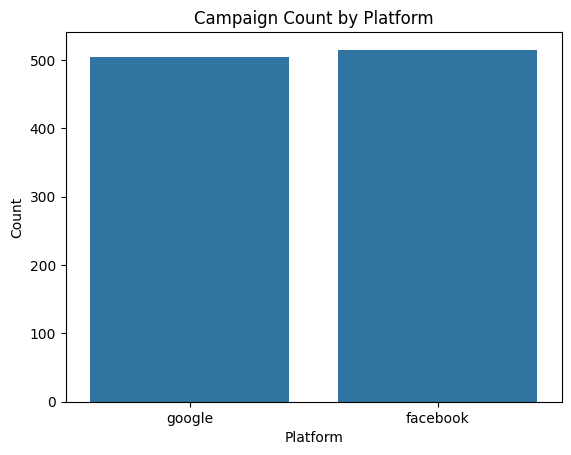

In [55]:
sns.countplot(data=df, x="Platform")
plt.title("Campaign Count by Platform")
plt.xlabel("Platform")
plt.ylabel("Count")
plt.show()

CONVERSION RATE ANALYSIS

Which platform performs better?

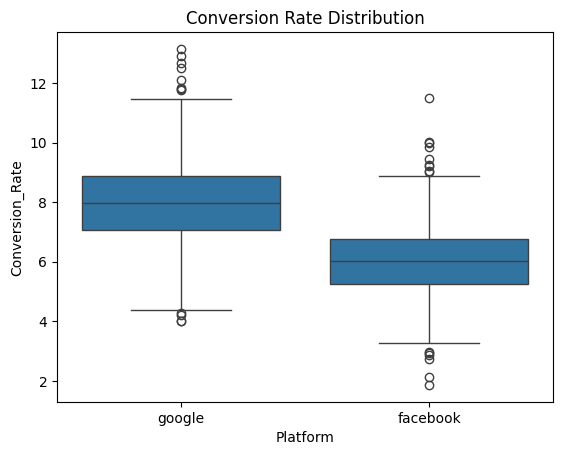

Platform
facebook    6.006343
google      7.990044
Name: Conversion_Rate, dtype: float64


In [51]:
Avg_conversion_rate = df.groupby('Platform')['Conversion_Rate'].mean()

sns.boxplot(data=df, x='Platform', y='Conversion_Rate')
plt.title("Conversion Rate Distribution")
plt.show()
print(Avg_conversion_rate)

REVENUE ANALYSIS

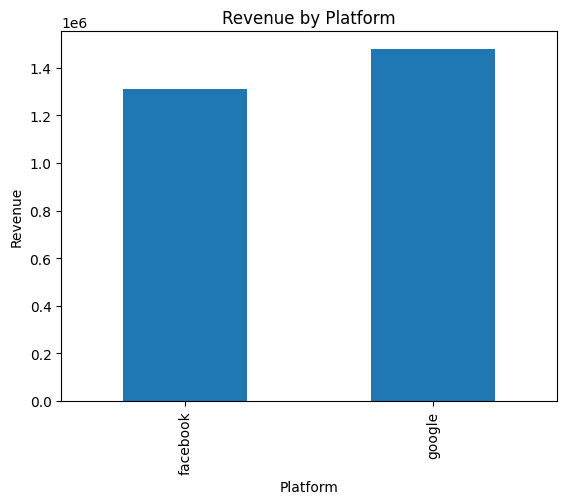

In [53]:
revenue = df.groupby('Platform')['Revenue'].sum()

revenue.plot(kind="bar")
plt.title('Revenue by Platform')
plt.ylabel('Revenue')
plt.show()

CTR ANALYSIS

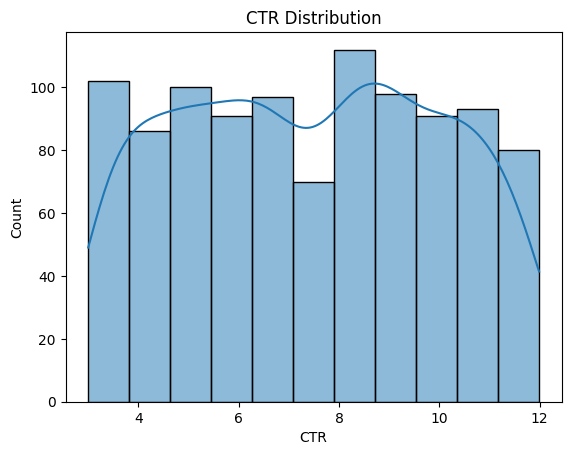

In [56]:
df.groupby('Platform')['CTR'].mean()

sns.histplot(data=df, x='CTR', kde=True)
plt.title('CTR Distribution')
plt.show()

CORRELATION ANALYSIS

In [57]:
corr = df.corr(numeric_only=True)
corr

,Ad_Spend,Impressions,Clicks,CTR,Conversions,Conversion_Rate,Revenue
Ad_Spend,1.000000,0.228475,0.160426,0.008368,0.139254,-0.009963,0.100448
Impressions,0.228475,1.000000,0.592787,-0.041646,0.539350,-0.008305,0.205057
Clicks,0.160426,0.592787,1.000000,0.707212,0.881426,0.007493,0.311089
CTR,0.008368,-0.041646,0.707212,1.000000,0.655748,0.007247,0.211506
Conversions,0.139254,0.539350,0.881426,0.655748,1.000000,0.392476,0.344907
Conversion_Rate,-0.009963,-0.008305,0.007493,0.007247,0.392476,1.000000,0.119635
Revenue,0.100448,0.205057,0.311089,0.211506,0.344907,0.119635,1.000000


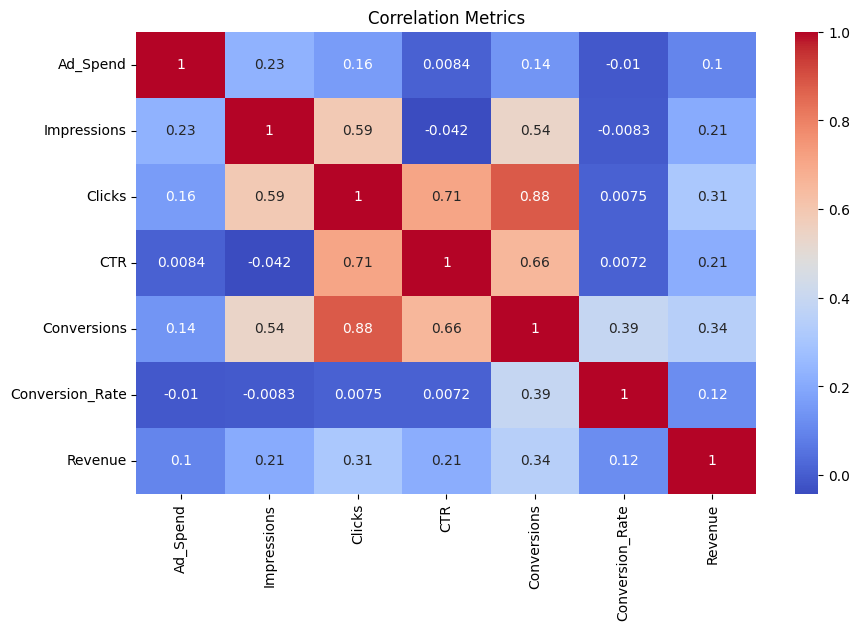

In [58]:
plt.figure(figsize=(10,6))
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title('Correlation Metrics')
plt.show()

In [ ]:
"""
INSIGHT:
Google Ads shows a higher average conversion rate compared to Facebook Ads.
This indicates Google campaigns may be more effective at driving purchases.
"""

In [60]:
df.to_csv('cleaned_marketing_campaign.csv', index=False)